## Preparar script de treino no Colab

Execute esta célula primeiro quando abrir apenas o notebook no Colab. Ela materializa `train_pivos_from_zip.py` no runtime, porque o Colab não copia automaticamente os outros arquivos do repositório quando você abre somente o `.ipynb`.

> A janela **Abrir notebook > GitHub** mostra somente notebooks (`.ipynb`), e não todos os arquivos da branch. Por isso `README.md`, arquivos `.py` e a pasta `gee/` não aparecem na lista da captura de tela, embora estejam versionados no GitHub.


In [ ]:
# Bootstrap Colab: garante que train_pivos_from_zip.py exista no runtime
from pathlib import Path

TRAIN_PIVOS_FROM_ZIP_SOURCE = '"""Treina uma U-Net simples para segmentação de pivôs a partir de um ZIP.\n\nEstrutura esperada dentro do ZIP (nomes configuráveis por CLI):\n\n    images/xxx.png   ou imagens/xxx.jpg\n    masks/xxx.png    ou mascaras/xxx.jpg\n\nOs arquivos de imagem e máscara são pareados pelo mesmo nome-base (`xxx`).\nEste script foi pensado para Colab, mas também roda localmente quando TensorFlow\nestá instalado.\n"""\n\nfrom __future__ import annotations\n\nimport argparse\nimport os\nimport shutil\nimport zipfile\nfrom pathlib import Path\nfrom typing import Iterable, Sequence\n\nimport tensorflow as tf\nfrom tensorflow.keras import callbacks, layers, models\n\nIMAGE_EXTENSIONS = {".png", ".jpg", ".jpeg"}\n\n\ndef extract_zip(zip_path: Path, output_dir: Path, overwrite: bool = False) -> Path:\n    """Extrai o ZIP de treinamento para `output_dir`."""\n    if not zip_path.exists():\n        raise FileNotFoundError(f"ZIP de treinamento não encontrado: {zip_path}")\n\n    if output_dir.exists() and overwrite:\n        shutil.rmtree(output_dir)\n    output_dir.mkdir(parents=True, exist_ok=True)\n\n    with zipfile.ZipFile(zip_path) as archive:\n        archive.extractall(output_dir)\n\n    return output_dir\n\n\ndef find_data_dir(root: Path, images_dir: str, masks_dir: str) -> Path:\n    """Localiza a pasta que contém os subdiretórios de imagens e máscaras."""\n    candidates = [root] + [path for path in root.rglob("*") if path.is_dir()]\n    for candidate in candidates:\n        if (candidate / images_dir).is_dir() and (candidate / masks_dir).is_dir():\n            return candidate\n    raise FileNotFoundError(\n        "Não encontrei a estrutura esperada no ZIP. "\n        f"Procurei subpastas \'{images_dir}/\' e \'{masks_dir}/\' em {root}."\n    )\n\n\ndef list_pairs(data_dir: Path, images_dir: str, masks_dir: str) -> list[tuple[Path, Path]]:\n    """Retorna pares imagem/máscara com o mesmo nome-base."""\n    image_root = data_dir / images_dir\n    mask_root = data_dir / masks_dir\n\n    images = {\n        path.stem: path\n        for path in image_root.rglob("*")\n        if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS\n    }\n    masks = {\n        path.stem: path\n        for path in mask_root.rglob("*")\n        if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS\n    }\n\n    common = sorted(images.keys() & masks.keys())\n    if not common:\n        raise FileNotFoundError(\n            "Nenhum par imagem/máscara foi encontrado. "\n            "Confirme se os arquivos têm o mesmo nome-base nas duas pastas."\n        )\n\n    return [(images[name], masks[name]) for name in common]\n\n\ndef decode_image(path: tf.Tensor, channels: int, image_size: tuple[int, int]) -> tf.Tensor:\n    """Lê PNG/JPEG e normaliza para [0, 1]."""\n    content = tf.io.read_file(path)\n    image = tf.io.decode_image(content, channels=channels, expand_animations=False)\n    image = tf.image.resize(image, image_size, method="bilinear")\n    image = tf.cast(image, tf.float32) / 255.0\n    return image\n\n\ndef build_dataset(\n    pairs: Sequence[tuple[Path, Path]],\n    image_size: tuple[int, int],\n    batch_size: int,\n    shuffle: bool,\n) -> tf.data.Dataset:\n    """Cria um `tf.data.Dataset` de pares imagem/máscara."""\n    image_paths = [str(image) for image, _ in pairs]\n    mask_paths = [str(mask) for _, mask in pairs]\n    dataset = tf.data.Dataset.from_tensor_slices((image_paths, mask_paths))\n\n    if shuffle:\n        dataset = dataset.shuffle(len(pairs), seed=42, reshuffle_each_iteration=True)\n\n    def load_pair(image_path: tf.Tensor, mask_path: tf.Tensor) -> tuple[tf.Tensor, tf.Tensor]:\n        image = decode_image(image_path, channels=3, image_size=image_size)\n        mask = decode_image(mask_path, channels=1, image_size=image_size)\n        mask = tf.cast(mask > 0.5, tf.float32)\n        return image, mask\n\n    return dataset.map(load_pair, num_parallel_calls=tf.data.AUTOTUNE).batch(batch_size).prefetch(tf.data.AUTOTUNE)\n\n\ndef conv_block(inputs: tf.Tensor, filters: int) -> tf.Tensor:\n    """Bloco convolucional padrão da U-Net."""\n    x = layers.Conv2D(filters, 3, padding="same", activation="relu")(inputs)\n    x = layers.BatchNormalization()(x)\n    x = layers.Conv2D(filters, 3, padding="same", activation="relu")(x)\n    x = layers.BatchNormalization()(x)\n    return x\n\n\ndef build_unet(image_size: tuple[int, int]) -> tf.keras.Model:\n    """Monta uma U-Net compacta para segmentação binária."""\n    inputs = layers.Input(shape=(image_size[0], image_size[1], 3))\n\n    c1 = conv_block(inputs, 32)\n    p1 = layers.MaxPooling2D()(c1)\n    c2 = conv_block(p1, 64)\n    p2 = layers.MaxPooling2D()(c2)\n    c3 = conv_block(p2, 128)\n    p3 = layers.MaxPooling2D()(c3)\n\n    bridge = conv_block(p3, 256)\n\n    u3 = layers.UpSampling2D()(bridge)\n    u3 = layers.Concatenate()([u3, c3])\n    c4 = conv_block(u3, 128)\n    u2 = layers.UpSampling2D()(c4)\n    u2 = layers.Concatenate()([u2, c2])\n    c5 = conv_block(u2, 64)\n    u1 = layers.UpSampling2D()(c5)\n    u1 = layers.Concatenate()([u1, c1])\n    c6 = conv_block(u1, 32)\n\n    outputs = layers.Conv2D(1, 1, activation="sigmoid", name="pivo_mask")(c6)\n    model = models.Model(inputs, outputs, name="unet_pivos")\n    model.compile(\n        optimizer="adam",\n        loss="binary_crossentropy",\n        metrics=["accuracy", tf.keras.metrics.BinaryIoU(target_class_ids=[1], threshold=0.5)],\n    )\n    return model\n\n\ndef split_pairs(pairs: Sequence[tuple[Path, Path]], validation_fraction: float) -> tuple[list[tuple[Path, Path]], list[tuple[Path, Path]]]:\n    """Divide pares em treino e validação sem aleatoriedade implícita."""\n    if not 0 < validation_fraction < 0.5:\n        raise ValueError("validation_fraction deve estar entre 0 e 0.5.")\n\n    validation_count = max(1, int(len(pairs) * validation_fraction))\n    train_count = len(pairs) - validation_count\n    if train_count < 1:\n        raise ValueError("São necessários pelo menos dois pares imagem/máscara para treinar.")\n\n    return list(pairs[:train_count]), list(pairs[train_count:])\n\n\ndef parse_image_size(value: str) -> tuple[int, int]:\n    """Converte `128` ou `128x128` em tupla de tamanho."""\n    if "x" in value.lower():\n        height, width = value.lower().split("x", maxsplit=1)\n        return int(height), int(width)\n    size = int(value)\n    return size, size\n\n\ndef build_arg_parser() -> argparse.ArgumentParser:\n    parser = argparse.ArgumentParser(description="Treina U-Net de pivôs a partir de um arquivo ZIP.")\n    parser.add_argument("--zip", required=True, type=Path, help="Caminho do ZIP com imagens e máscaras.")\n    parser.add_argument("--workdir", default=Path("/content/pivos_dataset"), type=Path, help="Pasta de extração do ZIP.")\n    parser.add_argument("--images-dir", default="images", help="Nome da pasta de imagens dentro do ZIP.")\n    parser.add_argument("--masks-dir", default="masks", help="Nome da pasta de máscaras dentro do ZIP.")\n    parser.add_argument("--image-size", default="128", help="Tamanho de entrada, por exemplo 128 ou 256x256.")\n    parser.add_argument("--batch-size", default=16, type=int, help="Tamanho do batch.")\n    parser.add_argument("--epochs", default=30, type=int, help="Número máximo de épocas.")\n    parser.add_argument("--validation-fraction", default=0.2, type=float, help="Fração dos pares usada para validação.")\n    parser.add_argument("--output", default=Path("Modelo_UNet_Pivos.keras"), type=Path, help="Arquivo .keras de saída.")\n    parser.add_argument("--overwrite", action="store_true", help="Reextrai o ZIP apagando o workdir existente.")\n    return parser\n\n\ndef main(argv: Iterable[str] | None = None) -> Path:\n    args = build_arg_parser().parse_args(argv)\n    image_size = parse_image_size(args.image_size)\n\n    extracted_dir = extract_zip(args.zip, args.workdir, overwrite=args.overwrite)\n    data_dir = find_data_dir(extracted_dir, args.images_dir, args.masks_dir)\n    pairs = list_pairs(data_dir, args.images_dir, args.masks_dir)\n    train_pairs, validation_pairs = split_pairs(pairs, args.validation_fraction)\n\n    print(f"Pares encontrados: {len(pairs)}")\n    print(f"Treino: {len(train_pairs)} | Validação: {len(validation_pairs)}")\n    print(f"Diretório de dados: {data_dir}")\n\n    train_ds = build_dataset(train_pairs, image_size, args.batch_size, shuffle=True)\n    validation_ds = build_dataset(validation_pairs, image_size, args.batch_size, shuffle=False)\n\n    model = build_unet(image_size)\n    model.summary()\n\n    args.output.parent.mkdir(parents=True, exist_ok=True)\n    training_callbacks = [\n        callbacks.ModelCheckpoint(args.output, monitor="val_loss", save_best_only=True),\n        callbacks.EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True),\n        callbacks.ReduceLROnPlateau(monitor="val_loss", patience=3, factor=0.5),\n    ]\n\n    model.fit(train_ds, validation_data=validation_ds, epochs=args.epochs, callbacks=training_callbacks)\n    model.save(args.output)\n    print(f"Modelo salvo em: {args.output}")\n    return args.output\n\n\nif __name__ == "__main__":\n    main()\n'

script_path = Path('train_pivos_from_zip.py')
if not script_path.exists():
    script_path.write_text(TRAIN_PIVOS_FROM_ZIP_SOURCE, encoding='utf-8')
    print(f'✅ Script criado no runtime do Colab: {script_path.resolve()}')
else:
    print(f'✅ Script já disponível: {script_path.resolve()}')

print(f'📦 Tamanho: {script_path.stat().st_size} bytes')
print('➡️  O arquivo está na aba Arquivos do runtime (ícone de pasta), não na janela Abrir notebook.')


🔄 Script de Retreinamento Seguro (Com Checkpoints)

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
import os
import glob
from google.colab import drive

# 1. Montar Drive (Obrigatório)
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# --- CONFIGURAÇÕES ---
pasta_base = '/content/drive/MyDrive/Tese_IA_Jussara'

# Busca o arquivo de dados JÁ EXISTENTE
busca = glob.glob(os.path.join(pasta_base, '*MASSIVE*tfrecord*'))
if not busca:
    # Se não achar o MASSIVE, pega qualquer um recente
    busca = glob.glob(os.path.join(pasta_base, '*tfrecord*'))
    busca.sort(key=os.path.getmtime, reverse=True)

caminho_arquivo = busca[0]
print(f"📂 Lendo dados de: {caminho_arquivo}")

# Parâmetros
KERNEL_SIZE = 128
READ_SIZE = 129
BATCH_SIZE = 32
EPOCHS = 40
INPUT_BANDS = ['R_1', 'NIR_1', 'NDVI_1', 'R_2', 'NIR_2', 'NDVI_2']
LABEL_BAND = 'label_chip'

# --- PIPELINE DE DADOS (Rápido) ---
def parse_and_process(example_proto):
    features_dict = {
        band: tf.io.VarLenFeature(tf.float32) for band in INPUT_BANDS + [LABEL_BAND]
    }
    parsed = tf.io.parse_single_example(example_proto, features_dict)

    inputs_list = []
    for band in INPUT_BANDS:
        dense = tf.sparse.to_dense(parsed[band], default_value=0.0)
        img = tf.reshape(dense, [READ_SIZE, READ_SIZE, 1])
        img = tf.image.resize_with_crop_or_pad(img, KERNEL_SIZE, KERNEL_SIZE)
        inputs_list.append(img)

    image_stacked = tf.concat(inputs_list, axis=-1)

    dense_lbl = tf.sparse.to_dense(parsed[LABEL_BAND], default_value=0.0)
    lbl = tf.reshape(dense_lbl, [READ_SIZE, READ_SIZE, 1])
    lbl = tf.image.resize_with_crop_or_pad(lbl, KERNEL_SIZE, KERNEL_SIZE)
    return image_stacked, lbl

# Contagem rápida para não dar erro de tamanho
print("🔢 Verificando tamanho do arquivo...")
raw_dataset = tf.data.TFRecordDataset(caminho_arquivo, compression_type='GZIP')
N_REAL = sum(1 for _ in raw_dataset)
print(f"✅ Total de amostras: {N_REAL}")

N_TRAIN = int(N_REAL * 0.8)
full_dataset = tf.data.TFRecordDataset(caminho_arquivo, compression_type='GZIP').map(parse_and_process)

train_ds = full_dataset.take(N_TRAIN).cache().shuffle(N_TRAIN).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_ds = full_dataset.skip(N_TRAIN).cache().batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# --- MODELO U-NET ---
def build_unet(input_shape):
    inputs = layers.Input(shape=input_shape)

    # Camadas (Encoder)
    c1 = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(inputs); p1 = layers.MaxPooling2D()(c1)
    c2 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(p1); p2 = layers.MaxPooling2D()(c2)
    c3 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(p2); p3 = layers.MaxPooling2D()(c3)

    # Bottleneck
    c4 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(p3)

    # Decoder
    u5 = layers.Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same')(c4)
    u5 = layers.concatenate([u5, c3])
    c5 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(u5)

    u6 = layers.Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(c5)
    u6 = layers.concatenate([u6, c2])
    c6 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(u6)

    u7 = layers.Conv2DTranspose(32, (2, 2), strides=(2, 2), padding='same')(c6)
    u7 = layers.concatenate([u7, c1])
    c7 = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(u7)

    outputs = layers.Conv2D(1, (1, 1), activation='sigmoid')(c7)
    return models.Model(inputs=[inputs], outputs=[outputs])

model = build_unet((KERNEL_SIZE, KERNEL_SIZE, 6))
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# --- 🛡️ SALVAMENTO AUTOMÁTICO (SEGURANÇA) ---
# Salva um backup no Drive a cada melhoria
checkpoint_path = os.path.join(pasta_base, 'Modelo_Checkpoint.keras')
checkpoint_cb = callbacks.ModelCheckpoint(
    filepath=checkpoint_path,
    save_best_only=False, # Salva sempre o último estado
    verbose=1
)

print("🔥 Iniciando Retreinamento (Vai salvar automaticamente no Drive)...")
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[checkpoint_cb] # <--- Aqui está a segurança
)

# Salvamento Final Definitivo
final_path = os.path.join(pasta_base, 'Modelo_UNet_Jussara_2025_FINAL_v2.keras')
model.save(final_path)
print(f"✅ SUCESSO! Modelo final salvo em: {final_path}")

📂 Lendo dados de: /content/drive/MyDrive/Tese_IA_Jussara/Chips_IA_Jussara_2025_MASSIVE.tfrecord.gz
🔢 Verificando tamanho do arquivo...
✅ Total de amostras: 4000
🔥 Iniciando Retreinamento (Vai salvar automaticamente no Drive)...
Epoch 1/40
    100/Unknown 37s 73ms/step - accuracy: 0.8045 - loss: 0.4626

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 1: saving model to /content/drive/MyDrive/Tese_IA_Jussara/Modelo_Checkpoint.keras
100/100 ━━━━━━━━━━━━━━━━━━━━ 58s 280ms/step - accuracy: 0.8049 - loss: 0.4620 - val_accuracy: 0.7590 - val_loss: 0.4728
Epoch 2/40
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.8713 - loss: 0.3133
Epoch 2: saving model to /content/drive/MyDrive/Tese_IA_Jussara/Modelo_Checkpoint.keras
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 81ms/step - accuracy: 0.8713 - loss: 0.3132 - val_accuracy: 0.7879 - val_loss: 0.4963
Epoch 3/40
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.8791 - loss: 0.2961
Epoch 3: saving model to /content/drive/MyDrive/Tese_IA_Jussara/Modelo_Checkpoint.keras
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 84ms/step - accuracy: 0.8791 - loss: 0.2961 - val_accuracy: 0.8253 - val_loss: 0.4014
Epoch 4/40
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.8810 - loss: 0.2900
Epoch 4: saving model to /content/drive/MyDrive/Tese_IA_Jussara/Modelo_Checkpoint.keras
100/100 ━━━━━━━━━━━━━━━━━━━━ 9

Passo 2: O Teste Visual (A Prova de Fogo)
Agora vamos fazer o teste final: vamos pedir para o Python carregar esse arquivo salvo (fingindo que somos um usuário novo) e aplicar em algumas imagens para ver se ele desenha os pivôs.

Abra um NOVO bloco de código nesse mesmo notebook e rode este script de validação:

--- INICIANDO PROVA REAL ---
✅ Arquivo do modelo encontrado: /content/drive/MyDrive/Tese_IA_Jussara/Modelo_UNet_Jussara_2025_FINAL_v2.keras
✅ Modelo carregado na memória com sucesso!
🔮 Gerando previsões com o modelo carregado...
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step

LEGENDA: Esquerda=Satélite | Meio=Gabarito | Direita=O que a IA Aprendeu


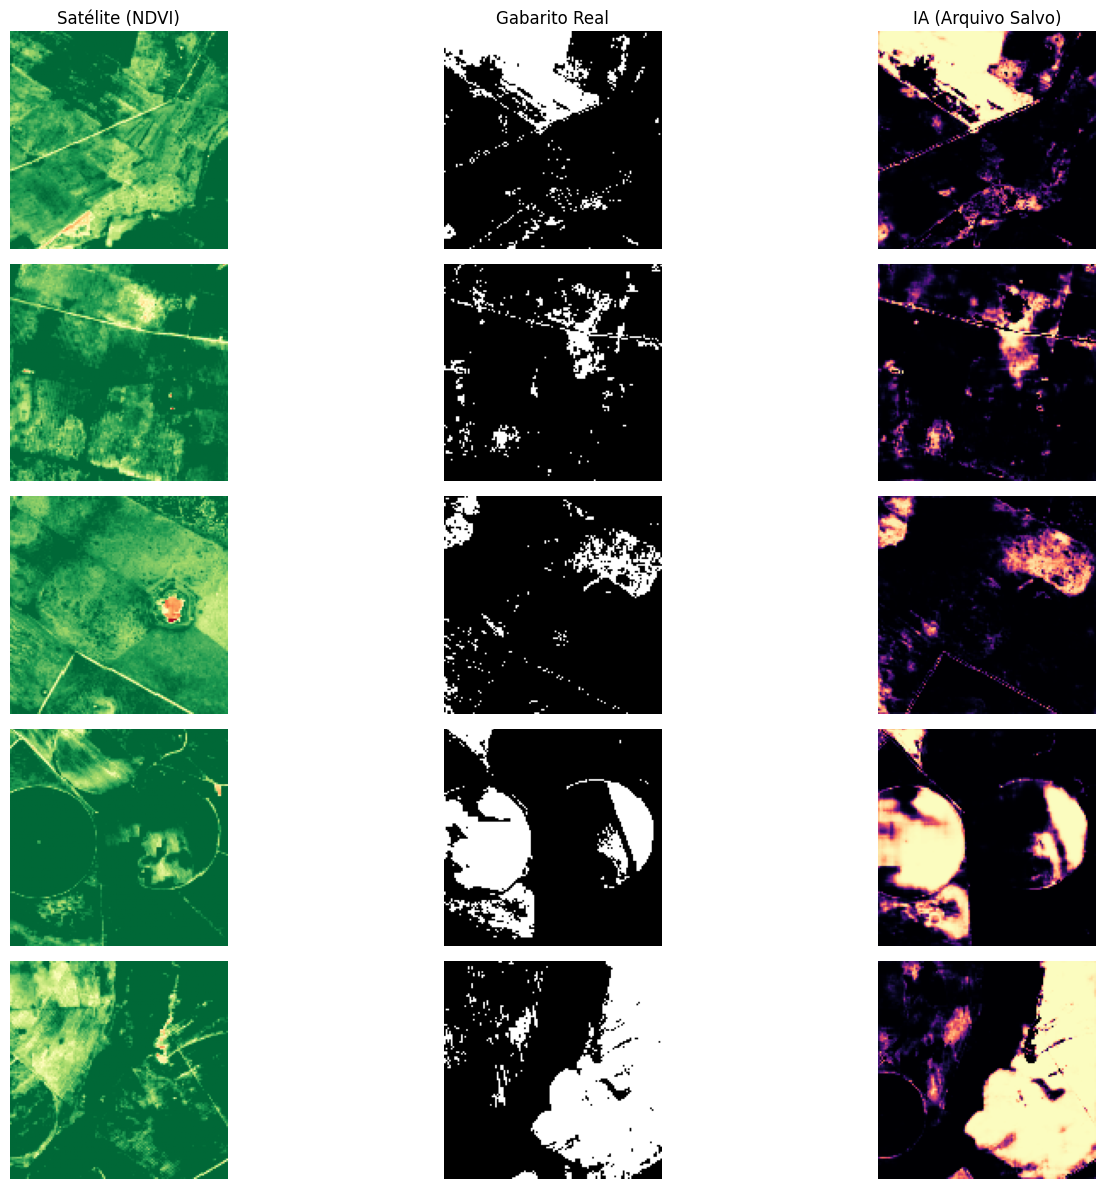

In [3]:
import tensorflow as tf
import matplotlib.pyplot as plt
import os
import glob
import numpy as np
from google.colab import drive

# 1. Montar Drive
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

print("--- INICIANDO PROVA REAL ---")

# 2. Localizar o Modelo Salvo
pasta_base = '/content/drive/MyDrive/Tese_IA_Jussara'
caminho_modelo = os.path.join(pasta_base, 'Modelo_UNet_Jussara_2025_FINAL_v2.keras')

if os.path.exists(caminho_modelo):
    print(f"✅ Arquivo do modelo encontrado: {caminho_modelo}")

    # CARREGAR O MODELO (O momento da verdade)
    try:
        model = tf.keras.models.load_model(caminho_modelo)
        print("✅ Modelo carregado na memória com sucesso!")
    except Exception as e:
        print(f"❌ ERRO ao carregar modelo: {e}")
else:
    print("❌ ERRO: O arquivo .keras não foi encontrado no local esperado.")

# 3. Carregar um pouco de dados para testar
# (Precisamos das imagens para passar pelo modelo)
busca_dados = glob.glob(os.path.join(pasta_base, '*MASSIVE*tfrecord*'))
caminho_dados = busca_dados[0]

KERNEL_SIZE = 128
READ_SIZE = 129
INPUT_BANDS = ['R_1', 'NIR_1', 'NDVI_1', 'R_2', 'NIR_2', 'NDVI_2']
LABEL_BAND = 'label_chip'

def parse_fast(example_proto):
    features_dict = {band: tf.io.VarLenFeature(tf.float32) for band in INPUT_BANDS + [LABEL_BAND]}
    parsed = tf.io.parse_single_example(example_proto, features_dict)
    inputs_list = []
    for band in INPUT_BANDS:
        dense = tf.sparse.to_dense(parsed[band], default_value=0.0)
        img = tf.reshape(dense, [READ_SIZE, READ_SIZE, 1])
        img = tf.image.resize_with_crop_or_pad(img, KERNEL_SIZE, KERNEL_SIZE)
        inputs_list.append(img)
    image_stacked = tf.concat(inputs_list, axis=-1)
    dense_lbl = tf.sparse.to_dense(parsed[LABEL_BAND], default_value=0.0)
    lbl = tf.reshape(dense_lbl, [READ_SIZE, READ_SIZE, 1])
    lbl = tf.image.resize_with_crop_or_pad(lbl, KERNEL_SIZE, KERNEL_SIZE)
    return image_stacked, lbl

# Pega apenas 1 lote de 10 imagens
dataset = tf.data.TFRecordDataset(caminho_dados, compression_type='GZIP')
dataset = dataset.map(parse_fast).batch(10).take(1)

# 4. Gerar Previsões
print("🔮 Gerando previsões com o modelo carregado...")
imgs, labels = next(iter(dataset))
preds = model.predict(imgs)

# 5. Visualizar
plt.figure(figsize=(15, 12))
print("\nLEGENDA: Esquerda=Satélite | Meio=Gabarito | Direita=O que a IA Aprendeu")

for i in range(5): # Mostra 5 exemplos
    # Satélite (NDVI Safra)
    plt.subplot(5, 3, i*3 + 1)
    plt.imshow(imgs[i][:,:,2], cmap='RdYlGn', vmin=0, vmax=0.8)
    plt.axis('off')
    if i==0: plt.title('Satélite (NDVI)')

    # Gabarito
    plt.subplot(5, 3, i*3 + 2)
    plt.imshow(labels[i][:,:,0], cmap='binary_r')
    plt.axis('off')
    if i==0: plt.title('Gabarito Real')

    # Predição da IA
    plt.subplot(5, 3, i*3 + 3)
    # Vmin/Vmax fixos para ver a confiança real
    plt.imshow(preds[i][:,:,0], cmap='magma', vmin=0, vmax=1)
    plt.axis('off')
    if i==0: plt.title('IA (Arquivo Salvo)')

plt.tight_layout()
plt.show()